# VLAB_06 — Karst System vs. SuperflexPy Lumped Models

Couples the physically-based vlab karst simulation (MODFLOW-CFP) with five
conceptual rainfall–runoff models built in SuperflexPy. The vlab system acts
as a "virtual reality" reference; each SuperflexPy model is calibrated to its
spring discharge using differential evolution.

| Step | Description |
|------|-------------|
| 1 | Run vlab at daily resolution (365 days, all-default parameters) — network + discharge plots |
| 2 | Define five SuperflexPy model structures (M1 … M5) |
| 3 | Calibrate each model to the vlab reference discharge |
| 4 | Plot and compare calibration results |

**SuperflexPy model structures**

| # | Structure | Free parameters |
|---|-----------|------------------|
| M1 | UnsaturatedReservoir → LinearReservoir | 5 |
| M2 | UnsaturatedReservoir → PowerReservoir | 6 |
| M3 | UnsaturatedReservoir → LinearReservoir → PowerReservoir | 7 |
| M4 | UnsaturatedReservoir → Splitter → PowerReservoir / PowerReservoir, PowerReservoir / None, Junction | 10 |
| M5 | UnsaturatedReservoir → Splitter → HalfTriangularLag→PowerReservoir / PowerReservoir / LinearReservoir → Junction | 12 |

All five models take daily precipitation and evapotranspiration as inputs
and are calibrated against the spring discharge of the vlab reference simulation.

**Why M5?** M1–M3 are purely serial and therefore have only one or two response
time scales. The reference hydrograph has three: near-vertical rising limbs
(concentrated recharge arriving through the conduits), a shoulder that decays
over one to two weeks, and a long, almost straight recession on top of a high
baseflow floor that persists through months without recharge. M4 is parallel and
does much better, but its splitter weight is hard-wired to 0.5/0.5, which fixes
the long-term water balance between its two branches. M5 is built as a direct
conceptual analogue of MODFLOW-CFP itself — one branch each for the three terms
that make up CFP's spring discharge, `Q_out = QMAT + QCADS + QTUB1…QTUB6` — with
a freely calibrated recharge partition and an explicit conduit travel time.

In [7]:
# import sys
# sys.path.insert(0, "../..")

import vlab
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## Configuration

In [8]:
RESOLUTION = "daily" # overall temporal resolution

N_STEPS = 365 # 365 # study window length, depends on resolution
START = 0 # starting index in the daily climate data
NSTP = 1 # 1 internal time step per MODFLOW stress period
N_WARMUP_TILES = 5 # how many times to tile the forcing for warmup (matches vlab.Epikarst n_tiles default)

# step 0 is the steady-state period, so we start with 1 here
time_steps  = np.arange(1, N_STEPS + 1)

WORKING_DIR = Path.cwd() / "runs"
WORKING_DIR.mkdir(exist_ok=True)

## Data Preparation

Load the bundled daily climate series at hourly resolution. Each daily value is
uniformly disaggregated to 24 hourly values (each hour = 1/24 of the daily total).
The study window is 10 days starting at daily index `START`.

Study period : 2016-01-01 00:00:00  —  2016-12-30 00:00:00
  Precipitation : mean = 2.7077 mm/h, total = 988.3 mm
  Evaporation   : mean = 1.3515 mm/h


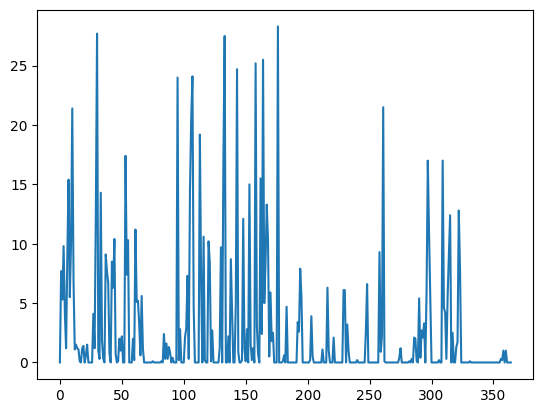

In [9]:
data_full = vlab.Data.default(temporal_resolution='daily')

data = vlab.Data(
    data_full.prec.iloc[START : START + N_STEPS],
    data_full.evap.iloc[START : START + N_STEPS],
)

print(f"Study period : {data.prec.index[0]}  —  {data.prec.index[-1]}")
print(f"  Precipitation : mean = {data.prec.mean():.4f} mm/h, "
      f"total = {data.prec.sum():.1f} mm")
print(f"  Evaporation   : mean = {data.evap.mean():.4f} mm/h")

plt.plot(data.prec.values)

## Reference vlab Simulation

Build a System with all parameter groups fixed at their defaults and
`temporal_resolution='hourly'`. The System automatically sets
`Groundwater.perlen = 3600 s` (one stress period = one hour).

The network is generated once and reused for the MODFLOW run, following
the same pattern as in VLAB_05.

In [10]:
s = vlab.System(
    temporal_resolution='daily',
    lay_elevs=[300., 0.],
    chb_spring=10.,
    delc=50.,
    delr=50.,
    n_rows=50,
    n_cols=100,
    groundwater=vlab.Groundwater(
        nstp=NSTP,
        nz=1,
        exe_name="C:/Users/MRudolph/Documents/GitHub/CFPy/CFPy_Examples/CFPv2.exe"),
    data=data,
    recharge_params=vlab.RechargeParams(
        stochastic=False,
        values={
            "srmax":  100.,   # maximum soil reservoir capacity (mm)
            "lp":     0.5,    # fraction of srmax below which ET is limited (-)
            "ks":     1000.,  # slow drainage coefficient from the soil store (mm/d)
            "gamma":  5.,     # non-linearity exponent for slow drainage (-)
            "simax":  2.,     # maximum interception storage capacity (mm)
            "kv":     1.,     # crop factor (multiplier of evapo(transpi)ration), (-)
            "omega":  0.3,    # fraction of soil drainage routed as quick flow to conduits (-)
        }),
    network_structure=vlab.NetworkStructure(
        stochastic=False,
        n_inlets=5, inlets_seed=123),
    network_properties=vlab.NetworkProperties(
        stochastic=False,
        values={"k_exchange": 1e-2, "diameter": 1.0}), # "k_exchange": 1e-2
    aquifer_params=vlab.AquiferParams(
        stochastic=False,
        values={"hk": 1e-4, "ss": 1e-7}), # "hk": 1e-2
)

print("Generating reference network...")
network = s.generate_network(
    random_state=None, working_dir=WORKING_DIR, cleanup=True, flat_network=True,
)
print(f"  inlets : {len(network.idxs_inlet)}  |  spring : {network.idxs_spring}")

Generating reference network...

Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.
  inlets : 5  |  spring : [100, 17, 1]


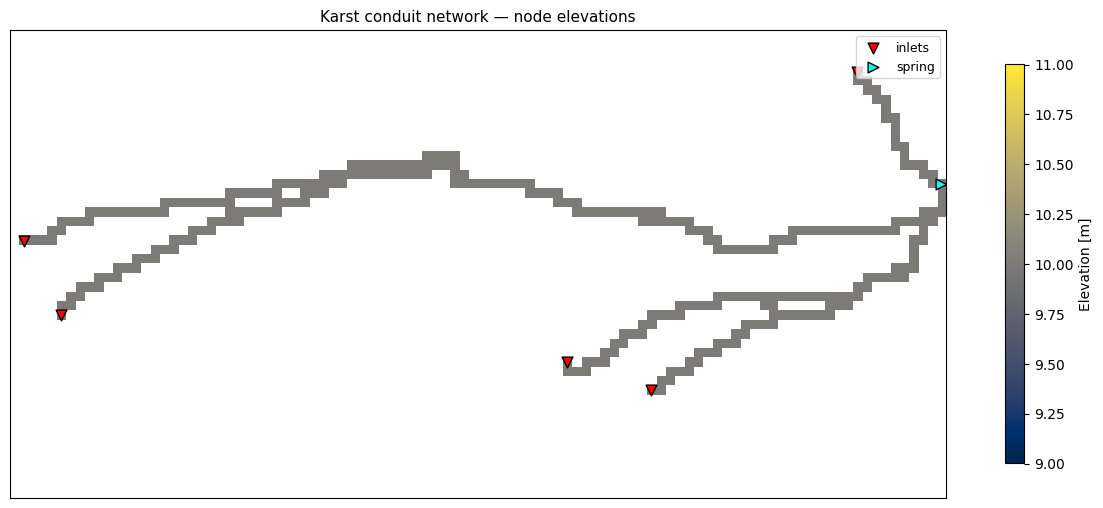

In [11]:
# Manually plot the conduit network: node elevations (colour) + inlet/spring markers.
# Cells with no conduit (elevation = 0) are shown as white (NaN).
fig, ax = plt.subplots(figsize=(12, 6))

nplot = network.validator.network.copy().astype(float)
nplot[nplot == 0] = np.nan

im = ax.matshow(nplot, cmap='cividis')
plt.colorbar(im, ax=ax, label='Elevation [m]', shrink=0.7)

inlets = np.array(network.idxs_inlet)   # shape (n_inlets, 3): [col, row, lay] 1-based
ax.scatter(inlets[:, 0] - 1, inlets[:, 1] - 1,
           c='r', marker='v', edgecolors='k', s=60, zorder=5, label='inlets')
ax.scatter([network.idxs_spring[0] - 1], [network.idxs_spring[1] - 1],
           c='cyan', marker='>', edgecolors='k', s=60, zorder=5, label='spring')

ax.set_xticks([])
ax.set_yticks([])
ax.legend(fontsize=9, loc='upper right')
plt.title('Karst conduit network — node elevations', fontsize=11)
plt.tight_layout()
plt.show()

In [12]:
print("Running reference simulation...")
success, Q_ref, heads = s.simulate_from_network(
    network, random_state=None, working_dir=WORKING_DIR, cleanup=False
)

if not success:
    raise RuntimeError("Reference simulation failed — check CFPv2.exe and model setup.")

# get recharge time series
# the recharge time series itself does NOT contain the steady state recharge, so we don't need to discard anything
rch = s.simulate_recharge() # / 24. # convert to mm/h

# Index 0 of Q_ref is the steady-state warm-up; skip it and convert m³/s → L/s
Q_ref_Ls = Q_ref.values[1:] * 1000

print(f"  Q_peak = {Q_ref_Ls.max():.3f} L/s  |  Q_mean = {Q_ref_Ls.mean():.3f} L/s  "
      f"|  length = {len(Q_ref_Ls)} steps")

Running reference simulation...
Elapsed time (.nbr file read): 0.07 s
Elapsed time (write nbr data): 0.21 s
  Q_peak = 496.717 L/s  |  Q_mean = 336.463 L/s  |  length = 365 steps


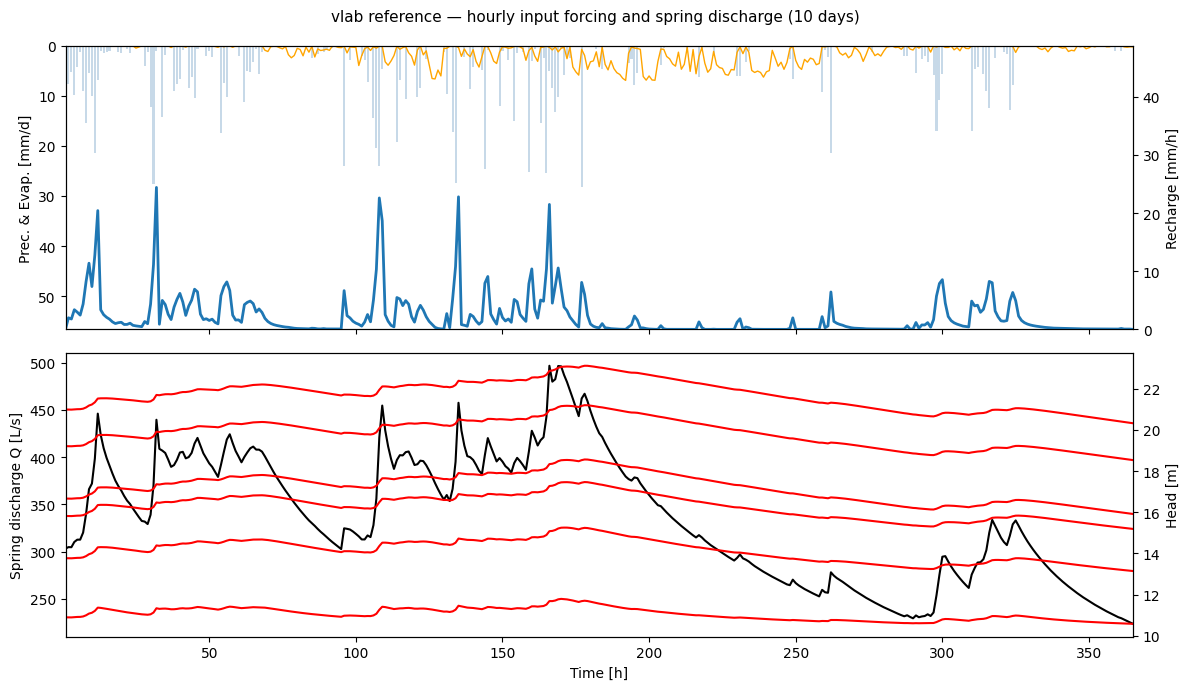

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

head_points = [
    [10, 10],
    [15, 15],
    [20, 20],
    [25, 25],
    [30, 30],
    [35, 35]
] # row, col

ax1_t = ax1.twinx()
ax2_t = ax2.twinx()

ax1.bar(time_steps, data.prec.values, color='steelblue', width=0.7, alpha=0.3)
ax1.plot(time_steps, data.evap.values, color='orange', lw=1.)
ax1.set_ylabel('Prec. & Evap. [mm/d]')
ax1.yaxis.set_inverted(True)
ax1.set_ylim(max([data.prec.values.max(), data.evap.values.max()]) * 2., 0.)

ax1_t.plot(time_steps, rch, lw=2.)
ax1_t.set_ylabel('Recharge [mm/h]')
ax1_t.set_ylim(0., rch.max() * 2.)

ax2.plot(time_steps, Q_ref_Ls, color='black', lw=1.5)
ax2.set_ylabel('Spring discharge Q [L/s]')
ax2.set_xlabel('Time [h]')

for p in head_points:
    ax2_t.plot(time_steps, heads[1:, 0, p[0], p[1]], color='red', lw=1.5)
ax2_t.set_ylabel(f'Head [m]')

ax2.set_xlim(time_steps[0], time_steps[-1])

plt.suptitle(
    'vlab reference — hourly input forcing and spring discharge (10 days)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

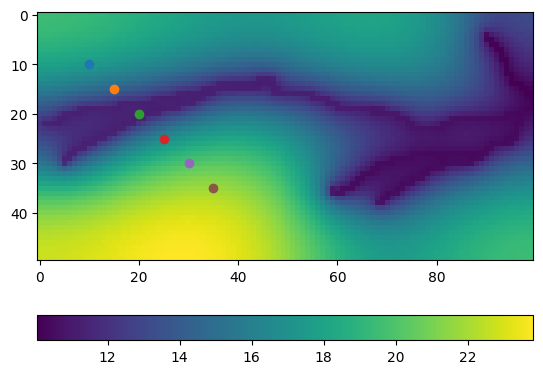

In [14]:
fig, ax = plt.subplots()

time_step = 40

im = ax.imshow(heads[time_step, 0, :, :])

for p in head_points:
    ax.scatter([p[0]], [p[1]])
plt.colorbar(im, orientation="horizontal")

## SuperflexPy Lumped Models

Five model structures are defined using SuperflexPy elements. All five share the
same upper zone element and differ only in how they route effective
precipitation to the spring. M1–M4 are HyMOD-inspired; M5 is built as a
conceptual analogue of the MODFLOW-CFP reference model itself.

> **Prerequisites** — if SuperflexPy is not yet installed, run
> `pip install superflexpy` in the active environment before executing the
> cells below.

The models run at daily resolution (`dt = 1.0`). Inputs are precipitation
and potential evapotranspiration in mm/d; output is discharge in mm/d,
converted to L/s via the vlab catchment area.

**Element descriptions**

| Element | SuperflexPy class | Role | Key parameters |
|---------|-------------------|------|----------------|
| Upper zone | `UnsaturatedReservoir` (HBV) | Soil moisture store — partitions P into ET and effective precipitation | Smax, Ce, m, beta |
| Linear reservoir | `LinearReservoir` (HyMOD) | Linear slow-flow routing | k [1/d] |
| Non-linear reservoir | `PowerReservoir` (HBV) | Power-law fast-flow routing | k [1/d], alpha |
| Lag | `HalfTriangularLag` (Thur) | Pure translation — conduit travel time from the swallow holes to the spring (M5 only) | lag-time [d] |
| Splitter / Junction / Transparent | `structure_elements` | Divide one flux over parallel branches, sum them again, and pad shorter branches so the layers stay rectangular | weight, direction |

**M5 — karst duality.** CFP's spring discharge is the sum of three physically
distinct contributions, `Q_out = QMAT + QCADS + QTUB1…QTUB6`. M5 gives each of
them its own parallel branch:

| Branch | CFP term | Elements | What it produces in the hydrograph |
|--------|----------|----------|------------------------------------|
| Conduit | QTUB | `HalfTriangularLag` → `PowerReservoir` | The steep, almost vertical rising limbs |
| CADS | QCADS | `PowerReservoir` | The 1–2 week shoulder after each peak |
| Matrix | QMAT | `LinearReservoir` (linear because CFP matrix flow is Darcian) | The long flat recession and the high baseflow floor |

The recharge partition over the three branches is calibrated via two nested
fractions, `f_quick` (quick karst system vs. matrix) and `f_tub` (conduit vs.
CADS within the quick system), which keeps every candidate parameter set valid.

In [15]:
try:
    from superflexpy.implementation.elements.hymod import LinearReservoir
    from superflexpy.implementation.elements.hbv import (
        UnsaturatedReservoir,
        PowerReservoir,
    )
    # HalfTriangularLag is a pure translation (travel-time) element; it is used
    # in M5 to represent the transit of concentrated recharge through the
    # conduit network from the swallow holes to the spring.
    from superflexpy.implementation.elements.thur_model_hess import HalfTriangularLag
    from superflexpy.implementation.root_finders.pegasus import PegasusPython, PegasusNumba
    from superflexpy.implementation.numerical_approximators.implicit_euler import (
        ImplicitEulerPython, ImplicitEulerNumba
    )
    from superflexpy.implementation.elements.structure_elements import Transparent, Junction, Splitter
    from superflexpy.framework.unit import Unit
    from scipy.optimize import differential_evolution
    print("SuperflexPy imported successfully.")
except ImportError as e:
    print(f"Import error: {e}")
    print("Install SuperflexPy with:  pip install superflexpy")
    raise

SuperflexPy imported successfully.


In [16]:
# ── Numerical solver ──────────────────────────────────────────────────────────
# A single approximator instance is shared across all elements because it
# holds no internal state (it is purely a method object).
root_finder  = PegasusNumba(iter_max=100)
approximator = ImplicitEulerNumba(root_finder=root_finder)

# ── Unit conversion: mm/h → L/s ───────────────────────────────────────────────
# The vlab default grid is 50 rows × 100 cols × 25 m × 25 m = 3 125 000 m².
# Q [L/s] = Q [mm/h] × A [m²] × (0.001 m/mm) / (3600 s/h) × (1000 L/m³)
#         = Q [mm/h] × A [m²] / 3600
AREA_M2 = s.n_rows * s.n_cols * s.delr * s.delc   # m²

def mm_h_to_Ls(q_mm_h):
    return q_mm_h * AREA_M2 / 3600.0

def mm_d_to_Ls(q_mm_d):
    return q_mm_d * AREA_M2 / 86400.

print(f"Catchment area : {AREA_M2 / 1e6:.3f} km²")
print(f"Unit check     : 1 mm/h over catchment = {mm_h_to_Ls(1.0):.1f} L/s")
print(f"Unit check     : 1 mm/d over catchment = {mm_d_to_Ls(1.0):.1f} L/s")

Catchment area : 12.500 km²
Unit check     : 1 mm/h over catchment = 3472.2 L/s
Unit check     : 1 mm/d over catchment = 144.7 L/s


## Model Definitions

Each `build_model_*` function constructs a SuperflexPy `Unit` configured with
`dt = 1.0` (one-hour time step). Unlike a naive setup that rebuilds the model
inside every objective-function evaluation, here each model is built **once**
(see the next cell) and then reused throughout calibration. During calibration
we only overwrite the free parameters and reset the internal stores — this is
far more efficient because the `Unit` structure and its numba solver bindings
are allocated a single time instead of thousands of times.

The `UnsaturatedReservoir` initial state `S0` is set to `Smax / 2` so that
each model starts with a partially filled soil store (neither empty nor
saturated). Because `Smax` changes during calibration, the objective function
re-applies `S0 = Smax / 2` after every `reset_states()` call (see below).

In [17]:
def build_model_1(Smax, Ce, m, beta, k_lr):
    # ── M1: UnsaturatedReservoir → LinearReservoir  (5 parameters) ───────────
    # The upper zone (uz) partitions hourly P and E_pot into actual ET and
    # effective precipitation. The linear reservoir (lr) routes effective
    # precipitation to the spring with a single recession coefficient.
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},   # start with half-filled soil store
        approximation=approximator,
        id='uz',
    )
    lr = LinearReservoir(
        parameters={'k': k_lr},
        states={'S0': 10.0},         # initial routing storage (mm)
        approximation=approximator,
        id='lr',
    )
    unit = Unit(layers=[[uz], [lr]], id='m1')
    unit.set_timestep(1.0)   # dt = 1 hour
    return unit


def build_model_2(Smax, Ce, m, beta, k_nr, alpha_nr):
    # ── M2: UnsaturatedReservoir → PowerReservoir  (6 parameters) ────────────
    # Same upper zone as M1. The power-law (non-linear) reservoir replaces the
    # linear routing, adding one extra free parameter (alpha).
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )
    nlr = PowerReservoir(
        parameters={'k': k_nr, 'alpha': alpha_nr},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr',
    )
    unit = Unit(layers=[[uz], [nlr]], id='m2')
    unit.set_timestep(1.0)
    return unit


def build_model_3(Smax, Ce, m, beta, k_lr, k_nr, alpha_nr):
    # ── M3: UnsaturatedReservoir → LinearReservoir → PowerReservoir  (7 params)
    # Cascade routing: effective precipitation first passes through the linear
    # slow-flow store, then through the non-linear fast-flow store. This gives
    # the model two routing time scales.
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )
    lr = LinearReservoir(
        parameters={'k': k_lr},
        states={'S0': 10.0},
        approximation=approximator,
        id='lr',
    )
    nlr = PowerReservoir(
        parameters={'k': k_nr, 'alpha': alpha_nr},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr',
    )
    unit = Unit(layers=[[uz], [lr], [nlr]], id='m3')
    unit.set_timestep(1.0)
    return unit

def build_model_4(Smax, Ce, m, beta, k_nr1, alpha_nr1, k_nr2, alpha_nr2, k_nr3, alpha_nr3):
    # ── M3: UnsaturatedReservoir → LinearReservoir → PowerReservoir  (7 params)
    # Cascade routing: effective precipitation first passes through the linear
    # slow-flow store, then through the non-linear fast-flow store. This gives
    # the model two routing time scales.
    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )

    nlr1 = PowerReservoir(
        parameters={'k': k_nr1, 'alpha': alpha_nr1},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr1',
    )

    nlr2 = PowerReservoir(
        parameters={'k': k_nr2, 'alpha': alpha_nr2},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr2',
    )

    nlr3 = PowerReservoir(
        parameters={'k': k_nr3, 'alpha': alpha_nr3},
        states={'S0': 10.0},
        approximation=approximator,
        id='nlr3',
    )

    t = Transparent(id='transparent')
    s = Splitter(
        weight=[[0.5], [0.5]],
        direction=[[0], [0]],
        id='splitter'
    )
    j = Junction(
        direction=[[0, 0]],
        id='junction'
    )

    unit = Unit(layers=[[uz], [s], [nlr1, nlr2], [nlr3, t], [j]], id='m4')
    unit.set_timestep(1.0)
    return unit


def build_model_5(Smax, Ce, m, beta,
                  t_lag, k_tub, alpha_tub, k_cads, alpha_cads, k_mat,
                  f_quick, f_tub):
    # ── M5: karst duality  (12 parameters) ───────────────────────────────────
    #    UZ → Splitter → [conduit | CADS | matrix] → Junction
    #
    # Unlike M1-M4, this structure is a deliberate conceptual analogue of the
    # MODFLOW-CFP reference model. In CFP the spring discharge is the sum of
    # three physically distinct contributions,
    #
    #     Q_out = QMAT + QCADS + QTUB1...QTUB6
    #
    # i.e. diffuse matrix flow, conduit-associated drainage storage (CADS) and
    # turbulent flow through the conduit tubes. M5 gives each of these its own
    # parallel branch:
    #
    #   * conduit branch (QTUB) : HalfTriangularLag → PowerReservoir
    #       The lag element represents the travel time of concentrated recharge
    #       from the swallow holes through the conduit network to the spring;
    #       the power reservoir is the flashy near-spring conduit storage.
    #       Together they produce the very steep, almost vertical rising limbs
    #       of the reference hydrograph, which the purely serial models M1-M3
    #       cannot reproduce at all.
    #
    #   * CADS branch (QCADS)   : PowerReservoir
    #       Intermediate store draining over roughly one to two weeks. This is
    #       the "shoulder" that follows each peak in the reference hydrograph.
    #
    #   * matrix branch (QMAT)  : LinearReservoir
    #       Large, slowly draining store. It is deliberately LINEAR because
    #       matrix flow in MODFLOW-CFP is Darcian. With a small recession
    #       coefficient it produces the long, nearly straight recession and the
    #       high baseflow floor (the reference never drops below ~200 L/s, even
    #       after months without recharge).
    #
    # ── How effective precipitation is partitioned over the three branches ───
    # SuperflexPy splitter weights are NOT parameters — they cannot be changed
    # through set_parameters() — so they are constructor arguments here and M5
    # is rebuilt on every objective-function evaluation (see make_objective_m5
    # in the calibration cell). Rebuilding costs about 0.1 ms against a ~14 ms
    # model solve, so the overhead is roughly 1 %.
    #
    # The partition is expressed as two NESTED fractions rather than as two
    # weights directly. That way every combination the optimiser can propose is
    # automatically valid (all three weights positive and summing to one), so no
    # candidate parameter set ever has to be rejected or renormalised:
    #
    #     f_quick : fraction of effective precipitation entering the QUICK
    #               karst system (conduits + CADS) rather than the matrix
    #     f_tub   : of that quick water, the fraction taking the conduit branch
    #               rather than the CADS branch
    w_tub  = f_quick * f_tub            # → conduit branch
    w_cads = f_quick * (1.0 - f_tub)    # → CADS branch
    w_mat  = 1.0 - f_quick              # → matrix branch

    uz = UnsaturatedReservoir(
        parameters={'Smax': Smax, 'Ce': Ce, 'm': m, 'beta': beta},
        states={'S0': Smax / 2.0},
        approximation=approximator,
        id='uz',
    )

    # Three-way splitter: one row per downstream branch. Every row draws from
    # the single upstream flux, hence direction index 0 everywhere.
    spl = Splitter(
        weight=[[w_tub], [w_cads], [w_mat]],
        direction=[[0], [0], [0]],
        id='spl',
    )

    # Conduit travel time. Lag elements take NO `approximation` argument: they
    # redistribute the incoming flux over a weight array instead of solving an
    # ODE. states={'lag': None} means "start with an empty lag array".
    lag = HalfTriangularLag(
        parameters={'lag-time': t_lag},
        states={'lag': None},
        id='lag',
    )

    tub = PowerReservoir(
        parameters={'k': k_tub, 'alpha': alpha_tub},
        states={'S0': 10.0},
        approximation=approximator,
        id='tub',
    )

    cads = PowerReservoir(
        parameters={'k': k_cads, 'alpha': alpha_cads},
        states={'S0': 10.0},
        approximation=approximator,
        id='cads',
    )

    # The matrix store starts much fuller than the two quick stores because it
    # has to sustain the baseflow floor. The exact value is not critical: with
    # k_mat bounded below at 0.003 1/d (time constant ~330 d) the four warmup
    # tiles (4 x 365 = 1460 d of spin-up) are enough for this store to
    # equilibrate before the scored study period begins.
    mat = LinearReservoir(
        parameters={'k': k_mat},
        states={'S0': 100.0},
        approximation=approximator,
        id='mat',
    )

    # Every layer must supply exactly as many fluxes as the next layer consumes.
    # The conduit branch is two elements deep while the CADS and matrix branches
    # are only one element deep, so the two short branches are padded with
    # Transparent elements to keep the layers rectangular.
    t1 = Transparent(id='t1')
    t2 = Transparent(id='t2')

    j = Junction(
        direction=[[0, 0, 0]],   # sum the three branch outputs into one flux
        id='junction',
    )

    #   layer 0     layer 1     layer 2     layer 3     layer 4
    #   [uz]    →   [spl]   →   [lag,   →   [tub,   →   [j]
    #                            cads,       t1,
    #                            mat]        t2]
    unit = Unit(layers=[[uz], [spl], [lag, cads, mat], [tub, t1, t2], [j]], id='m5')
    unit.set_timestep(1.0)
    return unit

In [18]:
# ── Build each model ONCE and prepare the (shared) forcing input ──────────────
# The models are constructed here with placeholder parameter values (the
# midpoint of each parameter's calibration bounds). These values are
# overwritten in every objective-function evaluation, so only the *structure*
# of each model matters at this point — not the specific numbers.

model_1 = build_model_1(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_lr=0.25)
model_2 = build_model_2(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_nr=0.25, alpha_nr=2.75)
model_3 = build_model_3(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_lr=0.25, k_nr=0.25, alpha_nr=2.75)
model_4 = build_model_4(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        k_nr1=0.25, alpha_nr1=2.75,
                        k_nr2=0.25, alpha_nr2=2.75,
                        k_nr3=0.25, alpha_nr3=2.75)

# M5 is the one exception to the "build once" rule: two of its free parameters
# (the splitter fractions f_quick and f_tub) are constructor arguments rather
# than SuperflexPy parameters, so its calibration rebuilds the model on every
# evaluation. The instance created here is therefore only used for the
# parameter-name printout below.
model_5 = build_model_5(Smax=255.0, Ce=1.05, m=0.05, beta=5.25,
                        t_lag=10.5,
                        k_tub=1.0, alpha_tub=3.0,
                        k_cads=0.25, alpha_cads=1.75,
                        k_mat=0.1,
                        f_quick=0.5, f_tub=0.5)

# Hourly forcing for the study period (mm/h).
prec_arr = data.prec.values
evap_arr = data.evap.values

# Tile the forcing N_WARMUP_TILES times so the model states can equilibrate
# before the actual study period. Only the last tile is scored in the
# objective function — identical to the warmup logic in vlab.Epikarst.
# The tiled input is the same for every calibration iteration, so we set it
# on each model just once, here, instead of re-setting it on every call.
prec_tiled = np.tile(prec_arr, N_WARMUP_TILES)
evap_tiled = np.tile(evap_arr, N_WARMUP_TILES)

for model in (model_1, model_2, model_3, model_4, model_5):
    model.set_input([prec_tiled, evap_tiled])

# Full hierarchical parameter names, in the SAME ORDER as the BOUNDS_* lists
# defined below. SuperflexPy names each parameter '<unit_id>_<element_id>_<param>'.
# These lists map the flat parameter vector handed to us by differential_evolution
# onto the named parameters of each pre-built model.
PARAM_NAMES_M1 = ['m1_uz_Smax', 'm1_uz_Ce', 'm1_uz_m', 'm1_uz_beta',
                  'm1_lr_k']
PARAM_NAMES_M2 = ['m2_uz_Smax', 'm2_uz_Ce', 'm2_uz_m', 'm2_uz_beta',
                  'm2_nlr_k', 'm2_nlr_alpha']
PARAM_NAMES_M3 = ['m3_uz_Smax', 'm3_uz_Ce', 'm3_uz_m', 'm3_uz_beta',
                  'm3_lr_k', 'm3_nlr_k', 'm3_nlr_alpha']
PARAM_NAMES_M4 = ['m4_uz_Smax', 'm4_uz_Ce', 'm4_uz_m', 'm4_uz_beta',
                  'm4_nlr1_k', 'm4_nlr1_alpha',
                  'm4_nlr2_k', 'm4_nlr2_alpha',
                  'm4_nlr3_k', 'm4_nlr3_alpha']
# M5 lists only its ten SuperflexPy parameters. Its two remaining free
# parameters, f_quick and f_tub, control the splitter weights and are handled
# separately (they are not addressable by name — see build_model_5).
PARAM_NAMES_M5 = ['m5_uz_Smax', 'm5_uz_Ce', 'm5_uz_m', 'm5_uz_beta',
                  'm5_lag_lag-time',
                  'm5_tub_k', 'm5_tub_alpha',
                  'm5_cads_k', 'm5_cads_alpha',
                  'm5_mat_k']

print("Models built once and forcing set:")
print(f"  M1 parameters: {model_1.get_parameters_name()}")
print(f"  M2 parameters: {model_2.get_parameters_name()}")
print(f"  M3 parameters: {model_3.get_parameters_name()}")
print(f"  M4 parameters: {model_4.get_parameters_name()}")
print(f"  M5 parameters: {model_5.get_parameters_name()}  + f_quick, f_tub (splitter)")

Models built once and forcing set:
  M1 parameters: ['m1_uz_Smax', 'm1_uz_Ce', 'm1_uz_m', 'm1_uz_beta', 'm1_lr_k']
  M2 parameters: ['m2_uz_Smax', 'm2_uz_Ce', 'm2_uz_m', 'm2_uz_beta', 'm2_nlr_k', 'm2_nlr_alpha']
  M3 parameters: ['m3_uz_Smax', 'm3_uz_Ce', 'm3_uz_m', 'm3_uz_beta', 'm3_lr_k', 'm3_nlr_k', 'm3_nlr_alpha']
  M4 parameters: ['m4_uz_Smax', 'm4_uz_Ce', 'm4_uz_m', 'm4_uz_beta', 'm4_nlr1_k', 'm4_nlr1_alpha', 'm4_nlr2_k', 'm4_nlr2_alpha', 'm4_nlr3_k', 'm4_nlr3_alpha']
  M5 parameters: ['m5_uz_Smax', 'm5_uz_Ce', 'm5_uz_m', 'm5_uz_beta', 'm5_lag_lag-time', 'm5_cads_k', 'm5_cads_alpha', 'm5_mat_k', 'm5_tub_k', 'm5_tub_alpha']  + f_quick, f_tub (splitter)


## Calibration

Each model is calibrated by minimising `1 − NSE` (Nash–Sutcliffe Efficiency)
against the vlab reference discharge using
`scipy.optimize.differential_evolution`.

The objective function runs the model over the tiled forcing, discards the
warmup tiles, keeps the 365-day study period, converts the output to L/s and
returns `1 − NSE`. Minimising this is equivalent to maximising NSE.

M1–M4 are built once and only have their parameters and states overwritten on
each evaluation. M5 is the exception: two of its free parameters set the
splitter weights, which are not SuperflexPy parameters, so M5 is rebuilt on
every call (~1 % overhead).

**Parameter bounds — M1 … M4**

| Parameter | Bounds | Notes |
|-----------|--------|-------|
| Smax | (10, 500) mm | Maximum soil storage |
| Ce | (0.1, 2.0) | ET efficiency coefficient |
| m | (0.001, 0.1) | Smoothing factor (numerical; not a physical parameter) |
| beta | (0.5, 10.0) | Non-linearity of runoff generation |
| k_lr | (0.001, 0.5) 1/d | Linear reservoir recession rate |
| k_nr | (0.001, 0.5) 1/d | Power reservoir coefficient |
| alpha_nr | (0.5, 5.0) | Power reservoir exponent |

**Parameter bounds — M5**

M5 shares the four upper-zone bounds above. Its routing bounds are set
separately, and deliberately do not overlap much, so that the three branches are
forced onto clearly separated time scales instead of collapsing onto each other.

| Parameter | Bounds | Notes |
|-----------|--------|-------|
| t_lag | (1, 5) d | Conduit travel time, swallow holes → spring |
| k_tub | (0.05, 2.0) 1/d | Conduit store — fast |
| alpha_tub | (1.0, 5.0) | Strongly non-linear (turbulent) release |
| k_cads | (0.005, 0.5) 1/d | CADS store — intermediate |
| alpha_cads | (0.5, 3.0) | |
| k_mat | (0.003, 0.2) 1/d | Matrix store — slow (time constant 5 … 330 d) |
| f_quick | (0.05, 0.95) | Fraction of recharge to the quick karst system vs. matrix |
| f_tub | (0.05, 0.95) | Fraction of quick water to the conduit vs. CADS |

Two of these bounds deserve a comment.

`t_lag` is deliberately narrow. It is a *conduit* travel time — water moving
through a few kilometres of open conduit at karstic velocities arrives within a
few days — so anything beyond about 5 days is not physically a conduit transit.
Allowing (1, 20) d instead does not just admit meaningless values, it actively
hurts the calibration: differential evolution then wanders into a region where
the conduit branch is given a long lag *and* a near-zero weight, i.e. it is
switched off, and the fit drops by roughly 0.01 NSE. With the tighter bound
`t_lag` settles reproducibly at 2.5–3.5 d across different DE seeds.

The lower bound on `k_mat` is set by the length of the spin-up, not by
hydrogeology: it is chosen so the matrix store still equilibrates within the four
warmup tiles (4 × 365 = 1460 d), because a slower store would make the result
depend on its arbitrary initial storage instead of on the forcing. The
calibration pushes `k_mat` right onto this bound, i.e. the model would prefer an
even slower matrix than the available spin-up can support. Relaxing the bound to
0.0005 1/d changes NSE by less than 0.01, so this is worth knowing about but not
worth trading the clean spin-up for.

In [19]:
def nse(Q_obs, Q_sim):
    # Nash-Sutcliffe Efficiency: 1.0 = perfect fit, 0 = mean benchmark.
    denom = np.sum((Q_obs - np.mean(Q_obs)) ** 2)
    if denom < 1e-12:
        return -np.inf   # observations have no variance — degenerate case
    return 1.0 - np.sum((Q_obs - Q_sim) ** 2) / denom


def make_objective(model, param_names, Q_obs, n):
    # Build the objective function for a PRE-BUILT SuperflexPy model.
    #
    # model       : a Unit created once in the cell above (with its tiled
    #               forcing already set via set_input).
    # param_names : full hierarchical parameter names (PARAM_NAMES_M*), in the
    #               same order as the parameter vector handed over by
    #               differential_evolution.
    # Q_obs       : observed (vlab reference) discharge in L/s, one value per
    #               study-period hour.
    # n           : number of study-period hours (= len(prec_arr)); used to
    #               discard the warmup tiles from the model output.
    #
    # Only the free parameters and the internal stores are updated on each call
    # — the model structure and its input are never rebuilt.
    def objective(params):
        # 1. Overwrite the free parameters on the pre-built model.
        param_values = {}
        for name, value in zip(param_names, params):
            param_values[name] = value
        model.set_parameters(param_values)

        # 2. Reset all internal stores to their build-time initial values
        #    (routing reservoirs back to S0 = 10 mm, soil store back to the
        #    placeholder value used at build time).
        model.reset_states()

        # 3. Re-initialise the soil store at half of the CURRENT Smax. This is
        #    needed because reset_states() only restores the build-time S0, but
        #    Smax changes from one candidate parameter set to the next. The first
        #    entry of param_names is always the '<unit>_uz_Smax' parameter, so
        #    the matching soil-state name is obtained by swapping the suffix.
        smax = param_values[param_names[0]]
        soil_state_name = param_names[0].replace('_Smax', '_S0')
        model.set_states({soil_state_name: smax / 2.0})

        # Small numerical negatives can appear at the start of a run; clip to zero.
        if RESOLUTION == "hourly":
            # 4. Run the model and discard the warmup tiles, keeping the last n steps.
            Q_sim_mm_h_full = model.get_output()[0]
            Q_sim_mm_h = Q_sim_mm_h_full[n * (N_WARMUP_TILES - 1):]
            Q_sim_Ls = mm_h_to_Ls(np.maximum(Q_sim_mm_h, 0.0))
        elif RESOLUTION == "daily":
            # 4. Run the model and discard the warmup tiles, keeping the last n steps.
            Q_sim_mm_d_full = model.get_output()[0]
            Q_sim_mm_d = Q_sim_mm_d_full[n * (N_WARMUP_TILES - 1):]
            Q_sim_Ls = mm_d_to_Ls(np.maximum(Q_sim_mm_d, 0.0))
        return 1.0 - nse(Q_obs, Q_sim_Ls)
    return objective


# ── M5 needs its own run/objective pair ───────────────────────────────────────
# Two of the twelve free parameters of M5 (the splitter fractions f_quick and
# f_tub) are constructor arguments rather than SuperflexPy parameters, so they
# cannot be applied to a pre-built model with set_parameters(). M5 is therefore
# REBUILT from scratch on every evaluation. Two convenient side effects:
#   * no state handling is needed at all — a freshly built model already starts
#     at S0 = Smax / 2, so the reset_states()/set_states() dance above is
#     unnecessary;
#   * the objective holds no shared mutable state.
# The cost is about 0.1 ms of construction against a ~14 ms model solve.
def run_model_5(params, n):
    # Run M5 for one candidate parameter set and return the study-period
    # discharge in L/s. `params` is the flat vector handed over by
    # differential_evolution, ordered exactly as BOUNDS_M5 below.
    # `n` is the number of study-period steps (= len(prec_arr)).
    Smax       = params[0]
    Ce         = params[1]
    m          = params[2]
    beta       = params[3]
    t_lag      = params[4]
    k_tub      = params[5]
    alpha_tub  = params[6]
    k_cads     = params[7]
    alpha_cads = params[8]
    k_mat      = params[9]
    f_quick    = params[10]
    f_tub      = params[11]

    model = build_model_5(Smax=Smax, Ce=Ce, m=m, beta=beta,
                          t_lag=t_lag,
                          k_tub=k_tub, alpha_tub=alpha_tub,
                          k_cads=k_cads, alpha_cads=alpha_cads,
                          k_mat=k_mat,
                          f_quick=f_quick, f_tub=f_tub)
    model.set_input([prec_tiled, evap_tiled])

    # Run the model, discard the warmup tiles and keep the last n steps.
    # Small numerical negatives can appear at the start of a run; clip to zero.
    if RESOLUTION == "hourly":
        Q_sim_mm_h_full = model.get_output()[0]
        Q_sim_mm_h = Q_sim_mm_h_full[n * (N_WARMUP_TILES - 1):]
        Q_sim_Ls = mm_h_to_Ls(np.maximum(Q_sim_mm_h, 0.0))
    elif RESOLUTION == "daily":
        Q_sim_mm_d_full = model.get_output()[0]
        Q_sim_mm_d = Q_sim_mm_d_full[n * (N_WARMUP_TILES - 1):]
        Q_sim_Ls = mm_d_to_Ls(np.maximum(Q_sim_mm_d, 0.0))
    return Q_sim_Ls


def make_objective_m5(Q_obs, n):
    # Same contract as make_objective, but for the rebuild-per-call M5.
    def objective(params):
        Q_sim_Ls = run_model_5(params, n)
        return 1.0 - nse(Q_obs, Q_sim_Ls)
    return objective


# ── Parameter bounds ──────────────────────────────────────────────────────────
BOUNDS_UZ = [
    (10.0,  500.0),   # Smax  [mm]
    ( 0.1,    2.0),   # Ce    [-]
    (0.001,   0.1),   # m     [-]
    ( 0.5,   10.0),   # beta  [-]
]
BOUNDS_LR  = [(0.001, 0.5)]            # k_lr  [1/h]
BOUNDS_NLR = [(0.001, 0.5),            # k_nr  [1/h]
              (  0.5, 5.0)]            # alpha [-]

BOUNDS_M1 = BOUNDS_UZ + BOUNDS_LR
BOUNDS_M2 = BOUNDS_UZ + BOUNDS_NLR
BOUNDS_M3 = BOUNDS_UZ + BOUNDS_LR + BOUNDS_NLR
BOUNDS_M4 = BOUNDS_UZ + BOUNDS_NLR + BOUNDS_NLR + BOUNDS_NLR

# M5 gets its own explicit bounds rather than reusing BOUNDS_LR / BOUNDS_NLR,
# because the whole point of the structure is that its three branches operate on
# clearly SEPARATED time scales. Giving each branch the same wide (0.001, 0.5)
# range would let the optimiser collapse them onto each other. The order here
# must match the unpacking in run_model_5 above.
BOUNDS_M5 = BOUNDS_UZ + [
    (  1.0,   5.0),   # t_lag       [d]    conduit travel time inlets → spring
    ( 0.05,   2.0),   # k_tub       [1/d]  conduit store — fast
    (  1.0,   5.0),   # alpha_tub   [-]    strongly non-linear (turbulent) release
    (0.005,   0.5),   # k_cads      [1/d]  CADS store — intermediate
    (  0.5,   3.0),   # alpha_cads  [-]
    (0.003,   0.2),   # k_mat       [1/d]  matrix store — slow (time const. 5…330 d)
    ( 0.05,  0.95),   # f_quick     [-]    quick karst system vs. matrix
    ( 0.05,  0.95),   # f_tub       [-]    conduit vs. CADS within the quick system
]

print(f"M1: {len(BOUNDS_M1)} parameters")
print(f"M2: {len(BOUNDS_M2)} parameters")
print(f"M3: {len(BOUNDS_M3)} parameters")
print(f"M4: {len(BOUNDS_M4)} parameters")
print(f"M5: {len(BOUNDS_M5)} parameters")

M1: 5 parameters
M2: 6 parameters
M3: 7 parameters
M4: 10 parameters
M5: 12 parameters


In [20]:
# prec_arr / evap_arr and the pre-built models (model_1/2/3) come from the
# "Build each model ONCE" cell above.
n_hours = len(prec_arr)   # study-period length, used to strip the warmup tiles

DE_KWARGS = dict(
    seed=42,
    maxiter=500,
    tol=1e-1,
    atol=1e-1,
    disp=True,   # set True to watch generation-by-generation convergence
    popsize=15,   # population size multiplier (15 × n_params individuals)
    workers=1,    # single-threaded: the objective mutates one shared model
                  # object, so parallel workers (workers>1) would be unsafe.
)

# ── Model 1: UnsaturatedReservoir → LinearReservoir ──────────────────────────
print("Calibrating Model 1 (UZ → LR)...")
res1 = differential_evolution(
    make_objective(model_1, PARAM_NAMES_M1, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M1,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res1.fun:.4f}  |  converged: {res1.success}")

# ── Model 2: UnsaturatedReservoir → PowerReservoir ───────────────────────────
print("Calibrating Model 2 (UZ → NLR)...")
res2 = differential_evolution(
    make_objective(model_2, PARAM_NAMES_M2, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M2,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res2.fun:.4f}  |  converged: {res2.success}")

# ── Model 3: UnsaturatedReservoir → LinearReservoir → PowerReservoir ─────────
print("Calibrating Model 3 (UZ → LR → NLR)...")
res3 = differential_evolution(
    make_objective(model_3, PARAM_NAMES_M3, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M3,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res3.fun:.4f}  |  converged: {res3.success}")

# ── Model 4: UnsaturatedReservoir → Splitter → [PowRes, PowRes] → [PowRes, -] → [Junction] ─────────
print("Calibrating Model 4 (UZ → [NLR, NLR] → [NLR, -] → [Junction])...")
res4 = differential_evolution(
    make_objective(model_4, PARAM_NAMES_M4, Q_ref_Ls, n_hours),
    bounds=BOUNDS_M4,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res4.fun:.4f}  |  converged: {res4.success}")

# ── Model 5: karst duality — UZ → Splitter → [conduit | CADS | matrix] → Junction ──
# This is the slowest of the five (12 free parameters, and the model is rebuilt
# on every evaluation), typically a couple of minutes.
print("Calibrating Model 5 (UZ → [Lag→NLR | NLR | LR] → [Junction])...")
res5 = differential_evolution(
    make_objective_m5(Q_ref_Ls, n_hours),
    bounds=BOUNDS_M5,
    **DE_KWARGS,
)
print(f"  NSE = {1 - res5.fun:.4f}  |  converged: {res5.success}")


# ── Evaluate best-fit simulations ─────────────────────────────────────────────
def eval_model(model, param_names, params, n):
    # Run a PRE-BUILT model for one fixed parameter set and return the
    # study-period discharge in L/s. Uses exactly the same parameter/state
    # handling as the objective function, so the evaluated simulation matches
    # what the calibration scored.
    param_values = {}
    for name, value in zip(param_names, params):
        param_values[name] = value
    model.set_parameters(param_values)

    model.reset_states()
    smax = param_values[param_names[0]]
    soil_state_name = param_names[0].replace('_Smax', '_S0')
    model.set_states({soil_state_name: smax / 2.0})

    if RESOLUTION == "hourly":
        Q_sim_mm_h_full = model.get_output()[0]
        Q_sim_mm_h = Q_sim_mm_h_full[n * (N_WARMUP_TILES - 1):]
        Q_sim_Ls = mm_h_to_Ls(np.maximum(Q_sim_mm_h, 0.0))
    elif RESOLUTION == "daily":
            Q_sim_mm_d_full = model.get_output()[0]
            Q_sim_mm_d = Q_sim_mm_d_full[n * (N_WARMUP_TILES - 1):]
            Q_sim_Ls = mm_d_to_Ls(np.maximum(Q_sim_mm_d, 0.0))
    return Q_sim_Ls


Q_cal1 = eval_model(model_1, PARAM_NAMES_M1, res1.x, n_hours)
Q_cal2 = eval_model(model_2, PARAM_NAMES_M2, res2.x, n_hours)
Q_cal3 = eval_model(model_3, PARAM_NAMES_M3, res3.x, n_hours)
Q_cal4 = eval_model(model_4, PARAM_NAMES_M4, res4.x, n_hours)
# M5 is rebuilt from its parameter vector rather than updated in place, so it
# uses run_model_5 (defined with its objective above) instead of eval_model.
Q_cal5 = run_model_5(res5.x, n_hours)


# ── Calibrated M5 parameters ──────────────────────────────────────────────────
# Worth inspecting: the three recession coefficients should come out on clearly
# separated time scales, and the two fractions say how the model chose to split
# the recharge between conduits, CADS and matrix. A coefficient sitting exactly
# on one of its bounds means that bound is too tight.
print("\nCalibrated M5 parameters:")
for name, value in zip(PARAM_NAMES_M5, res5.x):
    print(f"  {name:<18} = {value:.5f}")
f_quick_cal = res5.x[10]
f_tub_cal   = res5.x[11]
print(f"  {'f_quick':<18} = {f_quick_cal:.5f}")
print(f"  {'f_tub':<18} = {f_tub_cal:.5f}")
print(f"  → recharge partition:  conduit {f_quick_cal * f_tub_cal:.1%}  |  "
      f"CADS {f_quick_cal * (1 - f_tub_cal):.1%}  |  matrix {1 - f_quick_cal:.1%}")

Calibrating Model 1 (UZ → LR)...
differential_evolution step 1: f(x)= 0.6724946693402415
differential_evolution step 2: f(x)= 0.6724946693402415
differential_evolution step 3: f(x)= 0.6276267300220992
differential_evolution step 4: f(x)= 0.6265904145350362
differential_evolution step 5: f(x)= 0.5203035747282571
differential_evolution step 6: f(x)= 0.3690310532430914
differential_evolution step 7: f(x)= 0.3690310532430914
differential_evolution step 8: f(x)= 0.3670121682694354
differential_evolution step 9: f(x)= 0.3670121682694354
differential_evolution step 10: f(x)= 0.3670121682694354
differential_evolution step 11: f(x)= 0.3670121682694354
Polishing solution with 'L-BFGS-B'
  NSE = 0.6739  |  converged: True
Calibrating Model 2 (UZ → NLR)...
differential_evolution step 1: f(x)= 0.7591628533822896
differential_evolution step 2: f(x)= 0.6451412168298096
differential_evolution step 3: f(x)= 0.5392214408379314
differential_evolution step 4: f(x)= 0.5392214408379314
differential_evolutio

## Results

**Figure 1** — one panel per model: vlab reference (black) vs. calibrated
simulation (colour), with the NSE shown in the legend.

**Figure 2** — all five calibrated models overlaid with the vlab reference
on a common y-axis.

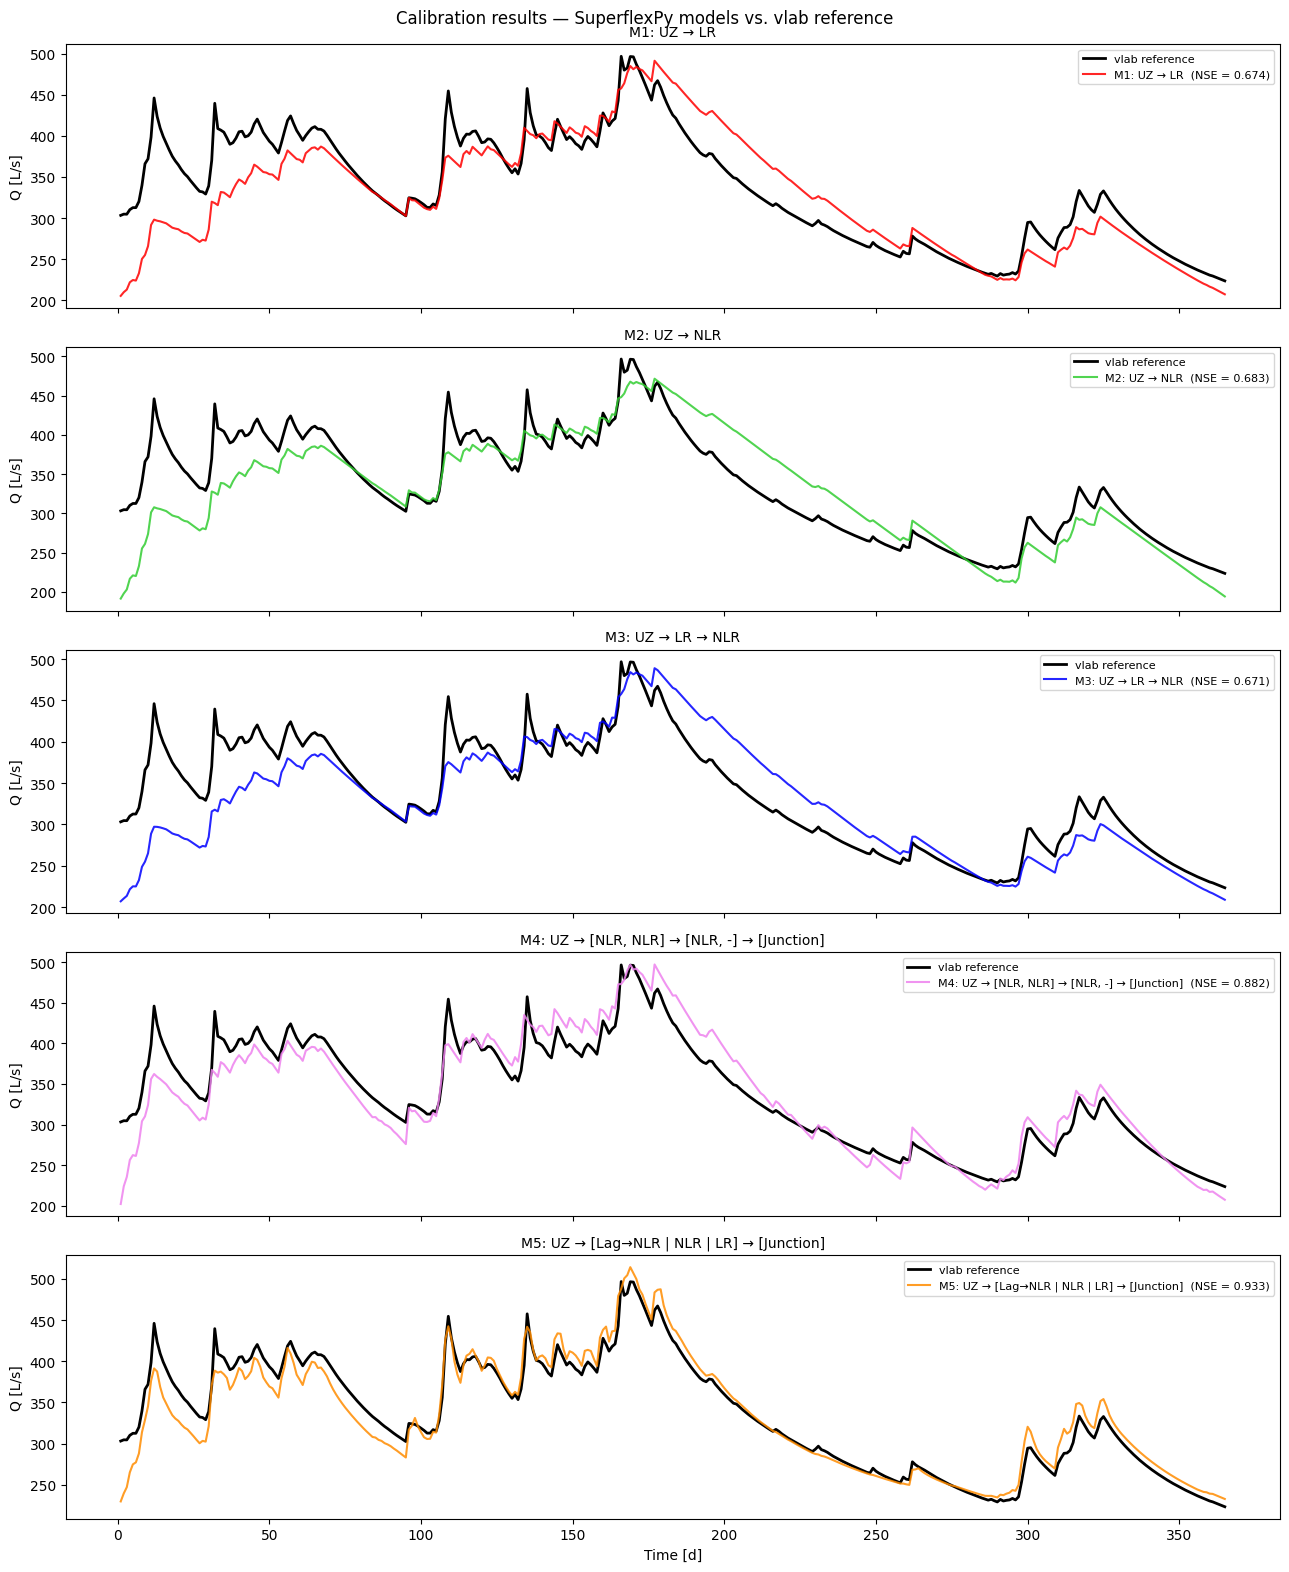

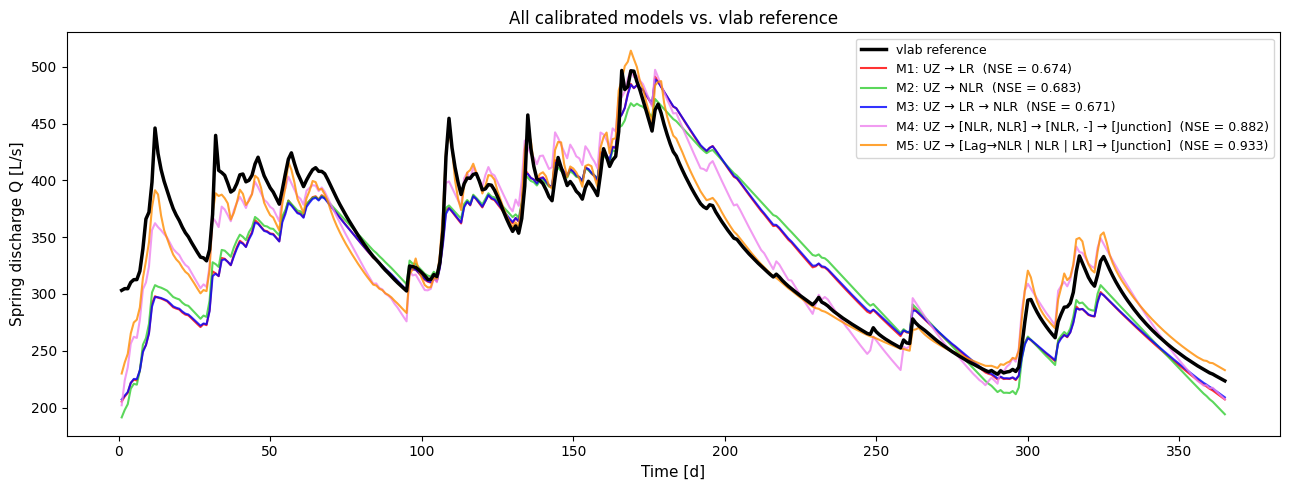

In [21]:
MODEL_COLORS = {'M1': "red", 'M2': 'limegreen', 'M3': 'blue', 'M4': 'violet',
                'M5': 'darkorange'}
MODEL_LABELS = {
    'M1': 'M1: UZ → LR',
    'M2': 'M2: UZ → NLR',
    'M3': 'M3: UZ → LR → NLR',
    'M4': 'M4: UZ → [NLR, NLR] → [NLR, -] → [Junction]',
    'M5': 'M5: UZ → [Lag→NLR | NLR | LR] → [Junction]',
}

# Single source of truth for what gets plotted and tabulated, so a new model
# only has to be added in one place.
MODEL_KEYS = ['M1', 'M2', 'M3', 'M4', 'M5']
MODEL_SERIES = [Q_cal1, Q_cal2, Q_cal3, Q_cal4, Q_cal5]

# ── Figure 1: one panel per model ─────────────────────────────────────────────
fig1, axes = plt.subplots(len(MODEL_KEYS), 1, figsize=(13, 16), sharex=True)

for ax, key, Q_cal in zip(axes, MODEL_KEYS, MODEL_SERIES):
    if Q_cal is None:
        continue
    nse_val = nse(Q_ref_Ls, Q_cal)
    ax.plot(time_steps, Q_ref_Ls, color='black', lw=2.0, label='vlab reference')
    ax.plot(time_steps, Q_cal, color=MODEL_COLORS[key], lw=1.5, alpha=0.85,
            label=f"{MODEL_LABELS[key]}  (NSE = {nse_val:.3f})")
    ax.set_ylabel('Q [L/s]')
    ax.set_title(MODEL_LABELS[key], fontsize=10)
    ax.legend(fontsize=8)

axes[-1].set_xlabel('Time [d]')
plt.suptitle('Calibration results — SuperflexPy models vs. vlab reference', fontsize=12)
plt.tight_layout()
plt.show()


# ── Figure 2: combined overlay (log scale) ────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(13, 5))

ax2.plot(time_steps, Q_ref_Ls, color='black', lw=2.5, zorder=10, label='vlab reference')
for key, Q_cal in zip(MODEL_KEYS, MODEL_SERIES):
    if Q_cal is None:
        continue
    nse_val = nse(Q_ref_Ls, Q_cal)
    ax2.plot(time_steps, Q_cal, color=MODEL_COLORS[key], lw=1.5, alpha=0.8,
             label=f"{MODEL_LABELS[key]}  (NSE = {nse_val:.3f})")

# ax2.set_yscale('log')
ax2.set_xlabel('Time [d]', fontsize=11)
ax2.set_ylabel('Spring discharge Q [L/s]', fontsize=11)
ax2.set_title('All calibrated models vs. vlab reference', fontsize=12)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [22]:
def rmse(Q_obs, Q_sim):
    return float(np.sqrt(np.mean((Q_obs - Q_sim) ** 2)))


print("\n── Calibration metrics ──────────────────────────────────────────────────")
header = f"{'Model':<48}  {'NSE':>7}  {'RMSE [L/s]':>11}  {'Peak err [L/s]':>15}"
print(header)
print("-" * len(header))

# MODEL_KEYS / MODEL_SERIES are defined in the plotting cell above.
for key, Q_cal in zip(MODEL_KEYS, MODEL_SERIES):
    if Q_cal is None:
        continue
    label    = MODEL_LABELS[key]
    nse_val  = nse(Q_ref_Ls, Q_cal)
    rmse_val = rmse(Q_ref_Ls, Q_cal)
    peak_err = abs(float(Q_ref_Ls.max()) - float(Q_cal.max()))
    print(f"{label:<48}  {nse_val:>7.4f}  {rmse_val:>11.3f}  {peak_err:>15.3f}")


── Calibration metrics ──────────────────────────────────────────────────
Model                                                 NSE   RMSE [L/s]   Peak err [L/s]
---------------------------------------------------------------------------------------
M1: UZ → LR                                        0.6739       38.202            5.391
M2: UZ → NLR                                       0.6827       37.683           25.099
M3: UZ → LR → NLR                                  0.6705       38.401            7.824
M4: UZ → [NLR, NLR] → [NLR, -] → [Junction]        0.8817       23.010            0.592
M5: UZ → [Lag→NLR | NLR | LR] → [Junction]         0.9334       17.269           17.430


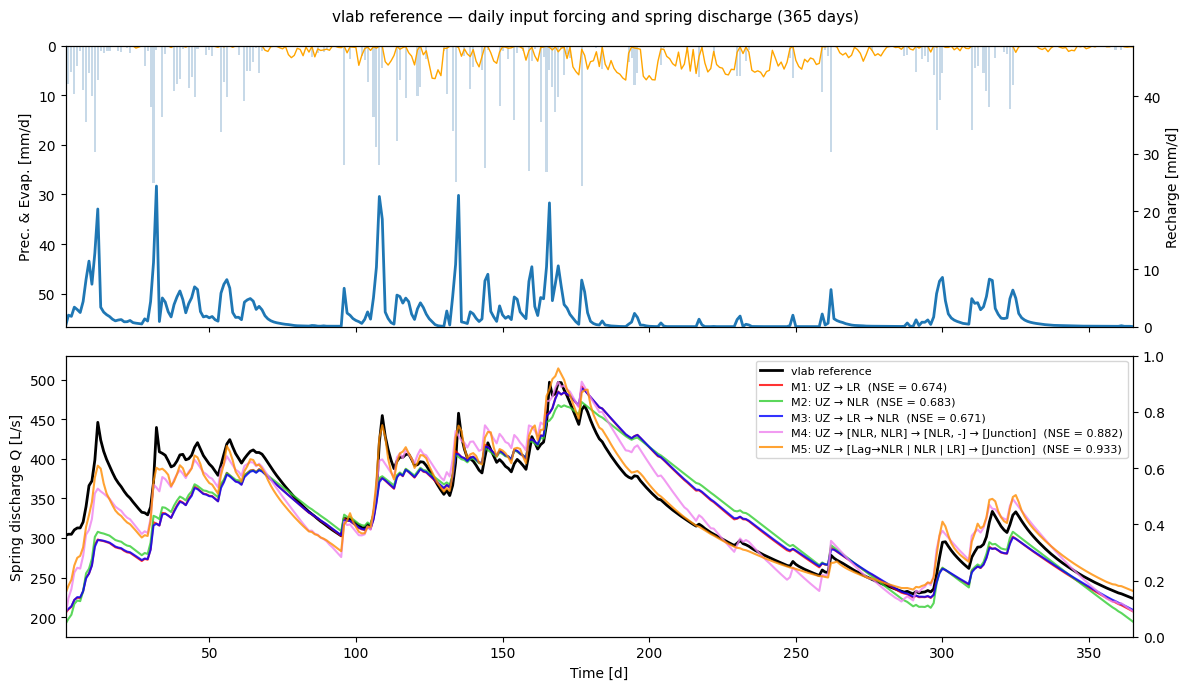

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1_t = ax1.twinx()
ax2_t = ax2.twinx()

ax1.bar(time_steps, data.prec.values, color='steelblue', width=0.7, alpha=0.3)
ax1.plot(time_steps, data.evap.values, color='orange', lw=1.)
ax1.set_ylabel('Prec. & Evap. [mm/d]')
ax1.yaxis.set_inverted(True)
ax1.set_ylim(max([data.prec.values.max(), data.evap.values.max()]) * 2., 0.)

ax1_t.plot(time_steps, rch, lw=2.)
ax1_t.set_ylabel('Recharge [mm/d]')
ax1_t.set_ylim(0., rch.max() * 2.)

ax2.plot(time_steps, Q_ref_Ls, color='black', lw=2., label='vlab reference')
ax2.set_ylabel('Spring discharge Q [L/s]')
ax2.set_xlabel('Time [d]')

# for p in head_points:
#     ax2_t.plot(time_steps, heads[1:, 0, p[0], p[1]], color='red', lw=1.5)
# ax2_t.set_ylabel(f'Head [m]')

# MODEL_KEYS / MODEL_SERIES are defined in the plotting cell above.
for key, Q_cal in zip(MODEL_KEYS, MODEL_SERIES):
    if Q_cal is None:
        continue
    nse_val = nse(Q_ref_Ls, Q_cal)
    ax2.plot(time_steps, Q_cal, color=MODEL_COLORS[key], lw=1.5, alpha=0.8,
             label=f"{MODEL_LABELS[key]}  (NSE = {nse_val:.3f})")

ax2.set_xlim(time_steps[0], time_steps[-1])
ax2.legend(fontsize=8)

plt.suptitle(
    'vlab reference — daily input forcing and spring discharge (365 days)',
    fontsize=11,
)
plt.tight_layout()
plt.show()